R² на обучающей выборке: 0.9400
R² на тестовой выборке: 0.9450
Коэффициенты: 86.5115
Смещение (bias): 2.4461


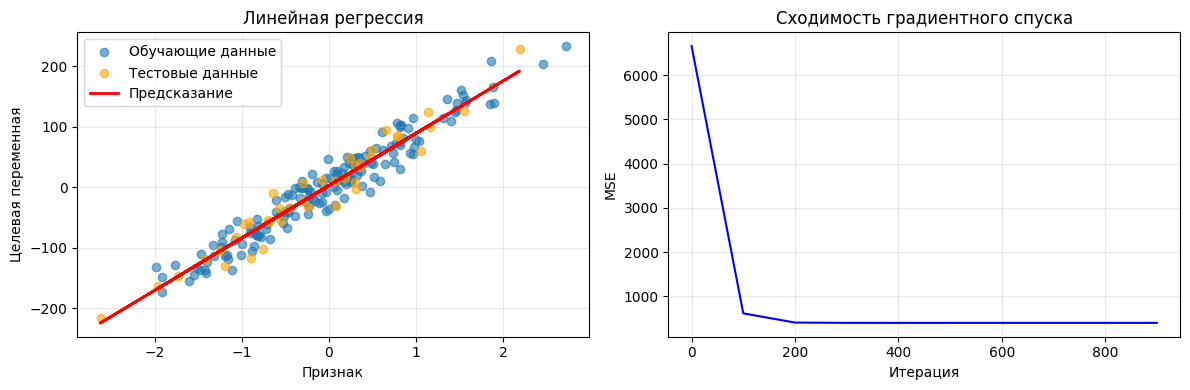


Пример с несколькими признаками
R² на тестовой выборке (3 признака): 0.9954
Коэффициенты: [83.07589567 81.58951341 16.27409026]
Смещение (bias): 0.3607

Сравнение с sklearn:
Наша реализация R²: 0.9954
sklearn R²: 0.9954
Наши веса: [83.07589567 81.58951341 16.27409026]
sklearn веса: [83.07589908 81.58951324 16.27410307]


In [1]:
# %% [markdown]
# # Линейная регрессия с нуля (без библиотек)
# Реализация линейной регрессии с помощью градиентного спуска

# %%
import numpy as np

class LinearRegressionFromScratch:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []  # Для отслеживания сходимости

    # 1. Функция потерь: среднеквадратичная ошибка (MSE)
    def _mse(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

    # 2. Метод обучения (подбор весов)
    def fit(self, X, y):
        """
        X - матрица (строки=объекты, столбцы=признаки)
        y - вектор целевых значений (непрерывные значения)
        """
        
        n_samples, n_features = X.shape
        
        # Инициализируем веса нулями или маленькими случайными числами
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Цикл обучения (градиентный спуск)
        for i in range(self.n_iterations):
            # Шаг А: Считаем линейную комбинацию (y_pred = X*w + b)
            y_predicted = np.dot(X, self.weights) + self.bias
            
            # Шаг Б: Считаем градиенты (производные функции потерь)
            # dJ/dw = (2/n) * X.T * (y_pred - y)
            dw = (2 / n_samples) * np.dot(X.T, (y_predicted - y))
            # dJ/db = (2/n) * sum(y_pred - y)
            db = (2 / n_samples) * np.sum(y_predicted - y)

            # Шаг В: Обновляем веса, делая шаг против градиента
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            # Сохраняем историю ошибок (для визуализации сходимости)
            if i % 100 == 0:
                loss = self._mse(y, y_predicted)
                self.loss_history.append(loss)

    # 3. Метод предсказания
    def predict(self, X):
        """Возвращает предсказанные значения"""
        return np.dot(X, self.weights) + self.bias
    
    # 4. Метод оценки качества (R-squared)
    def score(self, X, y):
        """
        Коэффициент детерминации R²
        R² = 1 - (SS_res / SS_tot)
        где SS_res - сумма квадратов остатков, SS_tot - общая сумма квадратов
        """
        y_pred = self.predict(X)
        
        # Сумма квадратов остатков
        ss_res = np.sum((y - y_pred) ** 2)
        # Общая сумма квадратов
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        
        return 1 - (ss_res / ss_tot)

# %%
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

# Генерируем данные для регрессии (1 признак для наглядности)
X, y = make_regression(n_samples=200, n_features=1, noise=20, random_state=42)

# Делим на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Создаем и обучаем нашу модель
model = LinearRegressionFromScratch(learning_rate=0.01, n_iterations=1000)
model.fit(X_train, y_train)

# 2. Делаем предсказания
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# 3. Оцениваем качество
r2_train = model.score(X_train, y_train)
r2_test = model.score(X_test, y_test)

print(f"R² на обучающей выборке: {r2_train:.4f}")
print(f"R² на тестовой выборке: {r2_test:.4f}")
print(f"Коэффициенты: {model.weights[0]:.4f}")
print(f"Смещение (bias): {model.bias:.4f}")

# %%
# Визуализация результатов для 1 признака
plt.figure(figsize=(12, 4))

# График 1: Регрессионная прямая
plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, alpha=0.6, label='Обучающие данные')
plt.scatter(X_test, y_test, alpha=0.6, color='orange', label='Тестовые данные')
plt.plot(X_test, y_pred_test, color='red', linewidth=2, label='Предсказание')
plt.xlabel('Признак')
plt.ylabel('Целевая переменная')
plt.title('Линейная регрессия')
plt.legend()
plt.grid(True, alpha=0.3)

# График 2: Сходимость градиентного спуска
plt.subplot(1, 2, 2)
plt.plot(range(0, model.n_iterations, 100), model.loss_history, 'b-')
plt.xlabel('Итерация')
plt.ylabel('MSE')
plt.title('Сходимость градиентного спуска')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# %%
# Пример с несколькими признаками
print("\n" + "="*50)
print("Пример с несколькими признаками")
print("="*50)

# Генерируем данные с 3 признаками
X_multi, y_multi = make_regression(n_samples=300, n_features=3, noise=10, random_state=42)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

# Обучаем модель
model_multi = LinearRegressionFromScratch(learning_rate=0.01, n_iterations=1000)
model_multi.fit(X_train_m, y_train_m)

# Оцениваем качество
r2_multi = model_multi.score(X_test_m, y_test_m)
print(f"R² на тестовой выборке (3 признака): {r2_multi:.4f}")
print(f"Коэффициенты: {model_multi.weights}")
print(f"Смещение (bias): {model_multi.bias:.4f}")

# %%
# Сравнение с эталонной реализацией из sklearn
from sklearn.linear_model import LinearRegression

sklearn_model = LinearRegression()
sklearn_model.fit(X_train_m, y_train_m)
sklearn_r2 = sklearn_model.score(X_test_m, y_test_m)

print("\nСравнение с sklearn:")
print(f"Наша реализация R²: {r2_multi:.4f}")
print(f"sklearn R²: {sklearn_r2:.4f}")
print(f"Наши веса: {model_multi.weights}")
print(f"sklearn веса: {sklearn_model.coef_}")